# Adaptive AM-FM Decomposition of Speech for Parkinson’s Disease Classification
## Support Vector Machine (SVM) Classification Pipeline using the PC-GITA Dataset

### Notebook Overview
This notebook implements a machine learning pipeline to distinguish between individuals with **Parkinson's Disease (PD)** and **Healthy Controls (HC)** based on acoustic features extracted from vowel phonations (/a/, /e/, /i/, /o/, /u/). 

The analysis focuses on high-frequency resolution features, specifically exploring variations in the first five harmonics ($H_1$ through $H_5$) derived from a high-resolution sinusoidal model named **eaQHM**, to identify potential vocal biomarkers associated with the pathology.

### Data Processing & Methodology
1.  **Data Ingestion:** Loading raw acoustic results from MATLAB (`.mat`) and merging with external subject metadata.
2.  **Feature Engineering:** Unpacking nested harmonic amplitude and frequency variation vectors into discrete scalar features.
3.  **Imputation & Cleaning:** Manual handling of missing demographic data and string normalization for phonetic identifiers.
4.  **Validation:** Multi-layered audits to ensure label consistency and speaker-independent integrity.
5.  **Model Training:** A **Repeated Nested Speaker-Independent Cross-Validation** (10x5 stratified) approach using a **SVM Classifier** to ensure robust performance estimates.
6.  **Evaluation:** Analyzing results at both the **Sample Level** (individual recordings) and **Subject Level** (aggregated speaker diagnosis), alongside **Permutation Importance** for feature interpretability.

### Data Ingestion and Feature Engineering

In [1]:
import pandas as pd
from scipy.io import loadmat

data_aeiou = loadmat('pc_gita_paper.mat')

data_aeiou = data_aeiou['results'].squeeze()
data_aeiou = pd.DataFrame(data_aeiou)
data_aeiou.columns=['centroid_mean', 'centroid_std', 'spectral_flux_mean', 'spectral_flux_max', 'teo_mean', 'teo_std', 'am_fm_corr', 'ampl_var', 'freq_var', 'f0_var', 'SRER', 
                    'jitter', 'jitter_T', 'shimmer', 'spectral_slope', 'f0_entropy', 'name']
file_names_aeiou = data_aeiou['name'].apply(lambda x: x[0])

data = data_aeiou.copy()

file_names = data['name'].apply(lambda x: x[0])

# Expand ampl_var and freq_var into separate harmonics
ampl_expanded = data['ampl_var'].apply(lambda x: x.flatten())
freq_expanded = data['freq_var'].apply(lambda x: x.flatten())

data['centroid_mean'] = data['centroid_mean'].apply(lambda x: x[0][0])
data['centroid_std']  = data['centroid_std'].apply(lambda x: x[0][0])
data['spectral_flux_mean'] = data['spectral_flux_mean'].apply(lambda x: x[0][0])
data['spectral_flux_max']  = data['spectral_flux_max'].apply(lambda x: x[0][0])
data['teo_mean']  = data['teo_mean'].apply(lambda x: x[0][0])
data['teo_std']   = data['teo_std'].apply(lambda x: x[0][0])
data['am_fm_corr'] = data['am_fm_corr'].apply(lambda x: x[0][0])

data['f0_var']   = data['f0_var'].apply(lambda x: x[0][0])
data['SRER']     = data['SRER'].apply(lambda x: x[0][0])
data['jitter']   = data['jitter'].apply(lambda x: x[0][0])
data['jitter_T'] = data['jitter_T'].apply(lambda x: x[0][0])
data['shimmer']  = data['shimmer'].apply(lambda x: x[0][0])
data['spectral_slope'] = data['spectral_slope'].apply(lambda x: x[0][0])
data['f0_entropy'] = data['f0_entropy'].apply(lambda x: x[0][0])

# Extract full speaker ID directly from file names
data['speaker'] = file_names.str.extract(r'([AC]\d{4})')[0]

# Gender information
gender_data = pd.read_csv("genders.txt", sep=",", header=0, names=["speaker", "gender"])
data = data.merge(gender_data, how="left", on="speaker")

# Assign label based on prefix: A=1 (pathological), C=0 (control)
data['label'] = data['speaker'].str[0].map({'A': 1, 'C': 0})

data['gender'] = data['gender'].map({'female': 0, 'male': 1})

# Drop unused features
data = data.drop(columns=['jitter_T', 'ampl_var', 'freq_var', 'am_fm_corr', 'f0_entropy', 'f0_var', 'SRER'])


### Harmonic Feature Expansion

In [2]:
for i in range(5):
    data[f'ampl_var_H{i+1}'] = ampl_expanded.apply(lambda v: v[i])

for i in range(5):
    data[f'freq_var_H{i+1}'] = freq_expanded.apply(lambda v: v[i])
    
print(data.head())
print(data.shape)
print(data.info())

   centroid_mean  centroid_std  spectral_flux_mean  spectral_flux_max  \
0     714.675371     29.409607            0.000006           0.000077   
1     684.376844     78.079107            0.000010           0.000073   
2     660.094305     86.520634            0.000007           0.000034   
3     285.987010     18.957543            0.000004           0.000032   
4     394.979610     35.093544            0.000010           0.000043   

   teo_mean   teo_std    jitter   shimmer  spectral_slope                name  \
0  6.073128  0.659364  0.000618  0.000252        0.154819  [AVPEPUDEAC0001a1]   
1  5.547715  1.321951  0.004522  0.000544        0.023326  [AVPEPUDEAC0001a2]   
2  5.315352  1.266671  0.001686  0.000290        0.067500  [AVPEPUDEAC0001a3]   
3  3.247028  0.871107  0.000504  0.000241        0.039277  [AVPEPUDEAC0003a1]   
4  6.094141  0.913145  0.001472  0.000189        0.253425  [AVPEPUDEAC0003a2]   

   ... ampl_var_H1  ampl_var_H2  ampl_var_H3  ampl_var_H4  ampl_var_H5  \


### Data Integrity and Label Validation

In [3]:
# Derive the label from speaker prefix
expected_label = data['speaker'].str[0].map({'A': 1, 'C': 0})

# Check for mismatches between expected and actual
incorrect = data.loc[data['label'] != expected_label, ['speaker', 'label']]

if incorrect.empty:
    print("All labels are correct according to speaker prefix.")
else:
    print("Incorrectly labeled speakers found:")
    print(incorrect.drop_duplicates())

# Check for consistency: each speaker should have exactly one label
speaker_labels = data.groupby('speaker')['label'].nunique()
bad_speakers = speaker_labels[speaker_labels > 1]

if bad_speakers.empty:
    print("No speaker has inconsistent labels.")
else:
    print("Speakers with inconsistent labels:")
    print(bad_speakers)
    
# Count total gender distribution
print("Total gender distribution:")
print(data[['speaker','gender']].drop_duplicates()['gender'].value_counts())

# Count per group (A vs C)
print("\nGender distribution per group:")
print(data[['speaker','gender','label']].drop_duplicates().groupby(['label','gender']).size())


All labels are correct according to speaker prefix.
No speaker has inconsistent labels.
Total gender distribution:
0    50
1    50
Name: gender, dtype: int64

Gender distribution per group:
label  gender
0      0         25
       1         25
1      0         25
       1         25
dtype: int64


### Final Preparation for Machine Learning

In [4]:
# Shuffle the data (optional)
random_state = 42

data = data.sample(frac=1, random_state=42).reset_index(drop=True)

groups = data['speaker']
print(len(groups.unique()), 'unique groups found.')
    
data = data.drop(columns=['speaker', 'name'])

print('Data shape:', data.shape)
print(data.head())
print(data.tail())

total_nans = data.isna().sum().sum()
print("Total NaNs in dataset:", total_nans)

print("NaNs per column:")
print(data.isna().sum())

100 unique groups found.
Data shape: (1500, 21)
   centroid_mean  centroid_std  spectral_flux_mean  spectral_flux_max  \
0     345.124596     33.961309        3.494791e-06           0.000020   
1     471.658167     69.391171        5.516790e-06           0.000085   
2     319.480597     13.182680        4.626802e-07           0.000007   
3     281.441332     11.407994        6.868375e-07           0.000006   
4     547.488393     42.830298        8.396353e-06           0.000031   

   teo_mean   teo_std    jitter   shimmer  spectral_slope  gender  ...  \
0  1.497782  1.001030  0.005022  0.000442       -0.598319       1  ...   
1  4.676804  1.872801  0.001687  0.000154       -1.128628       0  ...   
2 -0.202819  0.507286  0.000629  0.000136       -0.588079       1  ...   
3 -0.280084  0.721468  0.002325  0.000084       -0.606858       1  ...   
4  5.213957  0.945086  0.001713  0.000260       -0.461529       0  ...   

   ampl_var_H1  ampl_var_H2  ampl_var_H3  ampl_var_H4  ampl_var_H5  

### Repeated, 10-by-5 stratified (by gender and label) speaker-independent nested cross-validation

In [5]:
import pandas as pd
import numpy as np
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedGroupKFold, GridSearchCV
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, precision_score, recall_score
from sklearn.inspection import permutation_importance
from typing import Tuple


def aggregate_mean_by_group(y: np.ndarray, p: np.ndarray, g: np.ndarray) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Aggregate probabilities per cougher/group by mean. Cougher label is majority vote."""
    y = np.asarray(y).astype(int)
    p = np.asarray(p).astype(float)
    g = np.asarray(g)
    uniq = np.unique(g)
    y_g = np.zeros(len(uniq), dtype=int)
    p_g = np.zeros(len(uniq), dtype=float)

    for i, gg in enumerate(uniq):
        idx = np.where(g == gg)[0]
        p_g[i] = float(np.mean(p[idx])) if len(idx) else float('nan')
        y_g[i] = int(np.mean(y[idx]) >= 0.5) if len(idx) else 0

    return y_g, p_g, uniq


data['stratify_key'] = data['label'].astype(str) + "_" + data['gender'].astype(str)

X = data.drop(columns=['label', 'gender', 'stratify_key'])
y = data['label']
y_stratify = data['stratify_key'] 

# CONFIGURATION
N_REPEATS = 5  
N_OUTTER_SPLITS = 10   
N_INNER_SPLITS = 5
base_random_state = 42

# --- Storage for Results ---
metrics_template = {"accuracy": [], "f1": [], "auc": [], "precision": [], "recall": []}

results_sample = {k: [] for k in metrics_template}
results_speaker = {k: [] for k in metrics_template}

conf_matrices_sample = []
conf_matrices_speaker = []
all_perm_importances = [] 

print(f"Starting SVM Repeated Nested CV ({N_REPEATS} Repeats x {N_OUTTER_SPLITS} Folds)...")

for repeat in range(N_REPEATS):
    current_seed = base_random_state + repeat
    print(f"\n" + "="*80)
    print(f"REPEAT {repeat + 1}/{N_REPEATS} (Seed: {current_seed})")
    print("="*80)

    outer_cv = StratifiedGroupKFold(n_splits=N_OUTTER_SPLITS, shuffle=True, random_state=current_seed)
    inner_cv = StratifiedGroupKFold(n_splits=N_INNER_SPLITS, shuffle=True, random_state=current_seed)

    svm_pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('svc', SVC(probability=True, random_state=current_seed, class_weight='balanced'))
    ])

    param_grid = {
        "svc__C": [0.1, 1, 10, 100, 1000],
        "svc__gamma": ['scale', 1, 0.1, 0.01, 0.001, 0.0001],
        "svc__kernel": ['rbf'] 
    }

    for fold, (train_idx, test_idx) in enumerate(outer_cv.split(X, y_stratify, groups)):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        y_strat_train = y_stratify.iloc[train_idx]
        g_train, g_test = groups[train_idx], groups[test_idx]

        grid_search = GridSearchCV(
            estimator=svm_pipe,
            param_grid=param_grid,
            cv=inner_cv.split(X_train, y_strat_train, g_train),
            scoring="roc_auc",
            n_jobs=-1,
            verbose=0
        )
        grid_search.fit(X_train, y_train)
        best_model = grid_search.best_estimator_
        
        best_params = best_model.named_steps['svc'].get_params()
        best_C = best_params['C']
        best_gamma = best_params['gamma']
        best_kernel = best_params['kernel']

        # SAMPLE-LEVEL Predictions (Waveform)
        y_pred_sample = best_model.predict(X_test)
        y_proba_sample = best_model.predict_proba(X_test)[:, 1]

        results_sample["accuracy"].append(accuracy_score(y_test, y_pred_sample))
        results_sample["f1"].append(f1_score(y_test, y_pred_sample))
        results_sample["auc"].append(roc_auc_score(y_test, y_proba_sample))
        results_sample["precision"].append(precision_score(y_test, y_pred_sample))
        results_sample["recall"].append(recall_score(y_test, y_pred_sample))
        conf_matrices_sample.append(confusion_matrix(y_test, y_pred_sample))

        # SPEAKER-LEVEL Predictions (Subject)
        y_test_spk, y_proba_spk, speakers = aggregate_mean_by_group(y_test, y_proba_sample, g_test)
        y_pred_spk = (y_proba_spk >= 0.5).astype(int)

        results_speaker["accuracy"].append(accuracy_score(y_test_spk, y_pred_spk))
        results_speaker["f1"].append(f1_score(y_test_spk, y_pred_spk))
        results_speaker["auc"].append(roc_auc_score(y_test_spk, y_proba_spk))
        results_speaker["precision"].append(precision_score(y_test_spk, y_pred_spk))
        results_speaker["recall"].append(recall_score(y_test_spk, y_pred_spk))
        conf_matrices_speaker.append(confusion_matrix(y_test_spk, y_pred_spk))

        print(f"R{repeat+1} Fold {fold+1}: C={best_C}, Gamma={best_gamma}, Kernel={best_kernel}")
        print(f"   [Sample]  Acc: {results_sample['accuracy'][-1]:.4f} | F1: {results_sample['f1'][-1]:.4f} | AUC: {results_sample['auc'][-1]:.4f} | Prec: {results_sample['precision'][-1]:.4f} | Rec: {results_sample['recall'][-1]:.4f}")
        print(f"   [Speaker] Acc: {results_speaker['accuracy'][-1]:.4f} | F1: {results_speaker['f1'][-1]:.4f} | AUC: {results_speaker['auc'][-1]:.4f} | Prec: {results_speaker['precision'][-1]:.4f} | Rec: {results_speaker['recall'][-1]:.4f}")
        print("-" * 60)

        perm_result = permutation_importance(
            estimator=best_model,
            X=X_test,
            y=y_test,
            scoring='roc_auc',
            n_repeats=5,
            random_state=current_seed,
            n_jobs=-1
        )

        perm_df = pd.DataFrame({
            "feature": X_test.columns,
            "importance_mean": perm_result.importances_mean,
            "fold": (repeat * N_OUTTER_SPLITS) + fold + 1
        })
        all_perm_importances.append(perm_df)

print("\n" + "="*55)
print(f"FINAL SVM RESULTS ({N_REPEATS*N_OUTTER_SPLITS} Total Folds)")
print("="*55)
print(f"{'Metric':<12} | {'Sample-Level':<20} | {'Speaker-Level':<20}")
print("-" * 58)

for metric in metrics_template.keys():
    mean_samp = np.mean(results_sample[metric])
    std_samp = np.std(results_sample[metric])
    mean_spk = np.mean(results_speaker[metric])
    std_spk = np.std(results_speaker[metric])
    
    print(f"{metric.capitalize():<12} | {mean_samp:.4f} ± {std_samp:.4f}      | {mean_spk:.4f} ± {std_spk:.4f}")

perm_importances_df = pd.concat(all_perm_importances, axis=0)
final_perm_importance = perm_importances_df.groupby('feature')['importance_mean'].agg(['mean', 'std']).sort_values(by='mean', ascending=False)
print("\n--- Top 10 Features (Mean Decrease in AUC) ---")
print(final_perm_importance.head(10))

Starting SVM Repeated Nested CV (5 Repeats x 10 Folds)...

REPEAT 1/5 (Seed: 42)
R1 Fold 1: C=1, Gamma=scale, Kernel=rbf
   [Sample]  Acc: 0.6733 | F1: 0.7200 | AUC: 0.7479 | Prec: 0.6300 | Rec: 0.8400
   [Speaker] Acc: 0.7000 | F1: 0.7273 | AUC: 0.9200 | Prec: 0.6667 | Rec: 0.8000
------------------------------------------------------------
R1 Fold 2: C=1, Gamma=scale, Kernel=rbf
   [Sample]  Acc: 0.7600 | F1: 0.7831 | AUC: 0.8238 | Prec: 0.7143 | Rec: 0.8667
   [Speaker] Acc: 0.8000 | F1: 0.8333 | AUC: 0.8400 | Prec: 0.7143 | Rec: 1.0000
------------------------------------------------------------
R1 Fold 3: C=1, Gamma=scale, Kernel=rbf
   [Sample]  Acc: 0.7091 | F1: 0.7108 | AUC: 0.7021 | Prec: 0.6484 | Rec: 0.7867
   [Speaker] Acc: 0.7273 | F1: 0.7692 | AUC: 0.7000 | Prec: 0.6250 | Rec: 1.0000
------------------------------------------------------------
R1 Fold 4: C=1, Gamma=scale, Kernel=rbf
   [Sample]  Acc: 0.8400 | F1: 0.8442 | AUC: 0.9148 | Prec: 0.8228 | Rec: 0.8667
   [Speak

### Performance Evaluation and Feature Interpretability

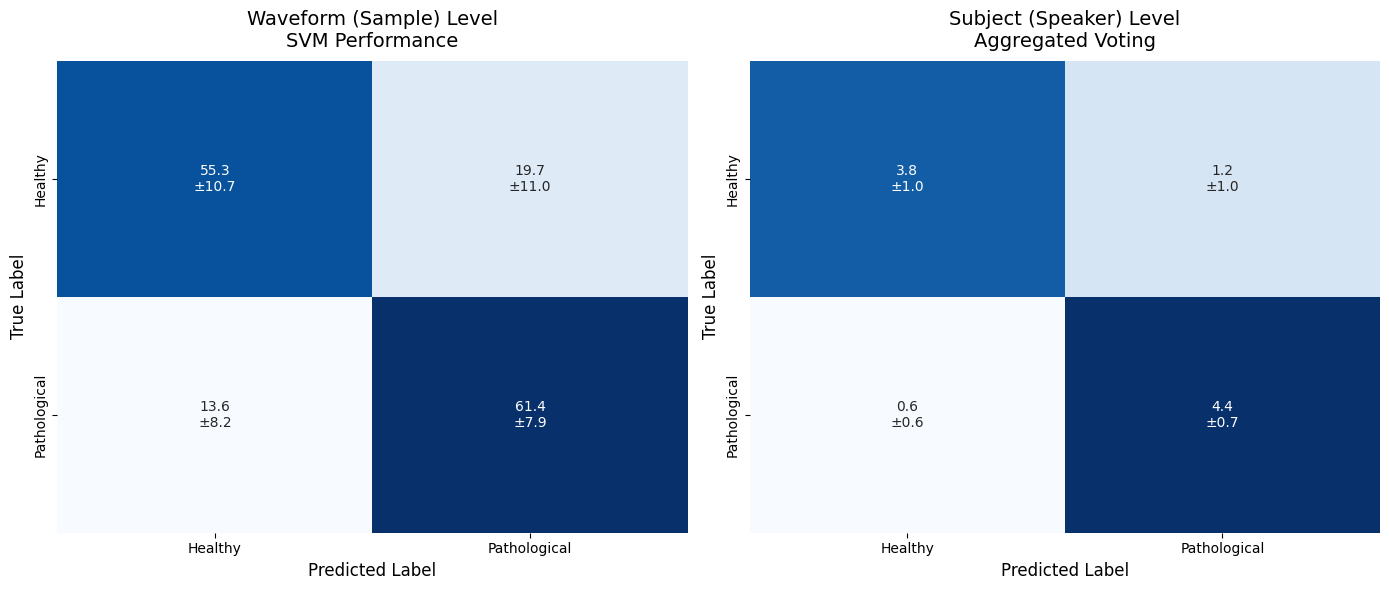

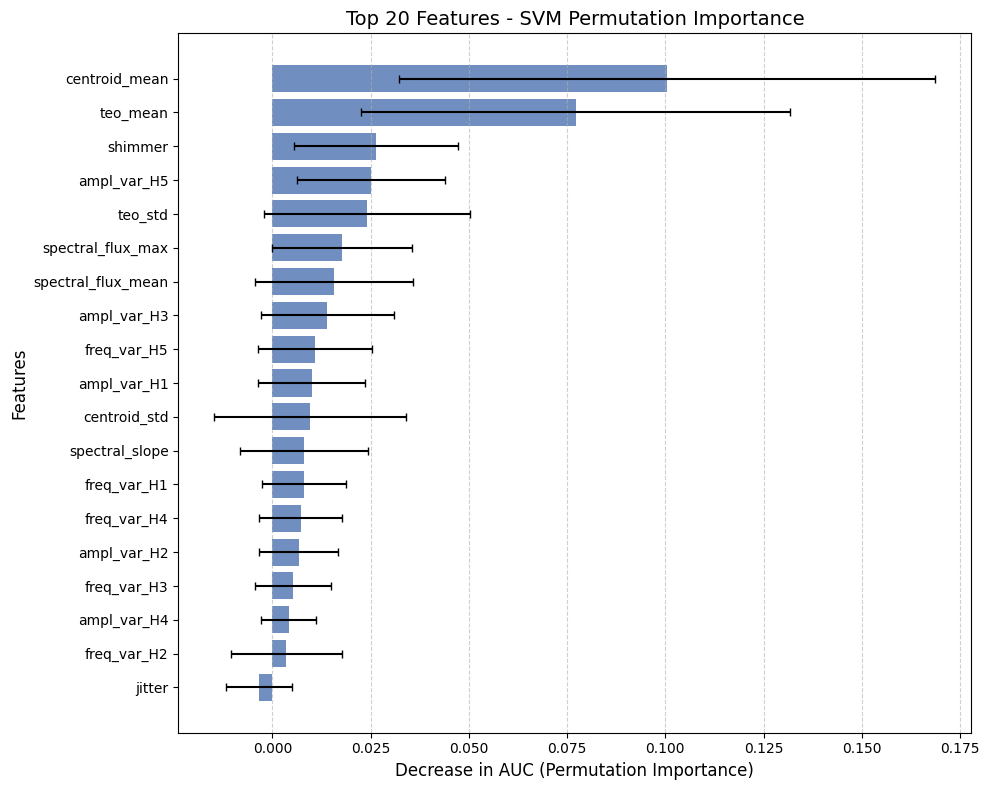

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


def plot_cm(cm_list, title, ax):
    cms = np.array(cm_list)
    mean_cm = np.mean(cms, axis=0)
    std_cm = np.std(cms, axis=0)
    
    annot = np.empty_like(mean_cm).astype(str)
    for i in range(mean_cm.shape[0]):
        for j in range(mean_cm.shape[1]):
            annot[i, j] = f"{mean_cm[i, j]:.1f}\n±{std_cm[i, j]:.1f}"
            
    sns.heatmap(mean_cm, annot=annot, fmt='', cmap='Blues', cbar=False, 
                xticklabels=['Healthy', 'Pathological'], 
                yticklabels=['Healthy', 'Pathological'], ax=ax)
    
    ax.set_title(title, fontsize=14, pad=10)
    ax.set_xlabel('Predicted Label', fontsize=12)
    ax.set_ylabel('True Label', fontsize=12)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

if len(conf_matrices_sample) > 0:
    plot_cm(conf_matrices_sample, 'Waveform (Sample) Level\nSVM Performance', axes[0])
else:
    axes[0].text(0.5, 0.5, 'No Data', ha='center')

if len(conf_matrices_speaker) > 0:
    plot_cm(conf_matrices_speaker, 'Subject (Speaker) Level\nAggregated Voting', axes[1])
else:
    axes[1].text(0.5, 0.5, 'No Data', ha='center')

plt.tight_layout()
plt.show()

if 'final_perm_importance' in locals():
    plot_data = final_perm_importance.head(20).sort_values(by='mean', ascending=True)

    plt.figure(figsize=(10, 8))
    plt.barh(
        plot_data.index,
        plot_data['mean'],
        xerr=plot_data['std'], 
        align='center',
        alpha=0.8,
        color='#4c72b0',
        ecolor='black',
        capsize=3
    )
    plt.xlabel("Decrease in AUC (Permutation Importance)", fontsize=12)
    plt.ylabel("Features", fontsize=12)
    plt.title("Top 20 Features - SVM Permutation Importance", fontsize=14)
    plt.grid(axis='x', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()
else:
    print("Feature importance data not found. Run the SVM analysis first.")